# EDA guiado por hipotesis

Este notebook valida las hipotesis escritas por el equipo en `reports/01_hipotesis.md`.

Criterio de trabajo:
- No se generan hipotesis nuevas automaticamente.
- Se usan graficos y tests para contrastar las hipotesis existentes.
- Los resultados son un borrador tecnico: despues deben revisarse manualmente antes de convertirse en conclusiones finales.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("../data/raw/datos.csv")
OUTPUT_DIR = Path("../outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Churn"


## Carga del dataset

Usamos el dataset raw para que el EDA contraste las hipotesis sobre los datos originales. Cuando una variable tiene faltantes, cada test usa los registros completos de esa variable.

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## Distribucion del target

Antes de validar hipotesis, miramos el peso relativo de churn y no churn para interpretar tasas y comparaciones.

In [3]:
target_summary = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET)
    .to_frame("clientes")
    .assign(porcentaje=lambda x: (x["clientes"] / len(df) * 100).round(2))
)
target_summary

,clientes,porcentaje
Churn,,
0,4682,83.16
1,948,16.84


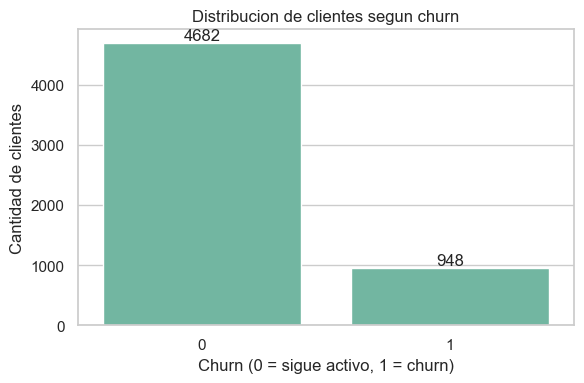

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, ax=ax)
ax.set_title("Distribucion de clientes segun churn")
ax.set_xlabel("Churn (0 = sigue activo, 1 = churn)")
ax.set_ylabel("Cantidad de clientes")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "target_distribution.png", dpi=150)
plt.show()

## Funciones auxiliares para tests

- Variables numericas vs target binario: Mann-Whitney U, porque no asumimos normalidad.
- Variables categoricas u ordinales vs target binario: chi-cuadrado de independencia.
- Reportamos p-valor y tama?o de efecto para no depender solo de significancia estadistica.


In [5]:
def format_pvalue(p_value):
    return "< 0.001" if p_value < 0.001 else f"{p_value:.4f}"


def mann_whitney_test(data, feature, target=TARGET):
    subset = data[[feature, target]].dropna()
    churn_values = subset.loc[subset[target] == 1, feature]
    no_churn_values = subset.loc[subset[target] == 0, feature]
    statistic, p_value = stats.mannwhitneyu(churn_values, no_churn_values, alternative="two-sided")
    rank_biserial = (2 * statistic) / (len(churn_values) * len(no_churn_values)) - 1
    return {
        "feature": feature,
        "test": "Mann-Whitney U",
        "n_used": len(subset),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": rank_biserial,
        "mean_churn": churn_values.mean(),
        "mean_no_churn": no_churn_values.mean(),
        "median_churn": churn_values.median(),
        "median_no_churn": no_churn_values.median(),
    }


def cramers_v(table):
    chi2, _, _, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan


def chi_square_test(data, feature, target=TARGET):
    subset = data[[feature, target]].dropna()
    table = pd.crosstab(subset[feature], subset[target])
    statistic, p_value, dof, expected = stats.chi2_contingency(table)
    return {
        "feature": feature,
        "test": "Chi-square",
        "n_used": len(subset),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": cramers_v(table),
        "dof": dof,
    }


def churn_rate_table(data, feature):
    return (
        data.groupby(feature)[TARGET]
        .agg(clientes="count", churn_rate="mean")
        .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
        .drop(columns="churn_rate")
        .reset_index()
    )


def plot_numeric_by_churn(data, feature, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=data, x=TARGET, y=feature, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Churn (0 = sigue activo, 1 = churn)")
    ax.set_ylabel(ylabel)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()


def plot_rate_by_category(data, feature, title, xlabel, filename):
    rates = churn_rate_table(data, feature)
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=rates, x=feature, y="churn_rate_pct", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Tasa de churn (%)")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    return rates

## H1 - Tenure

**Hipotesis:** Los clientes con menor `Tenure` tienden a churnear mas.

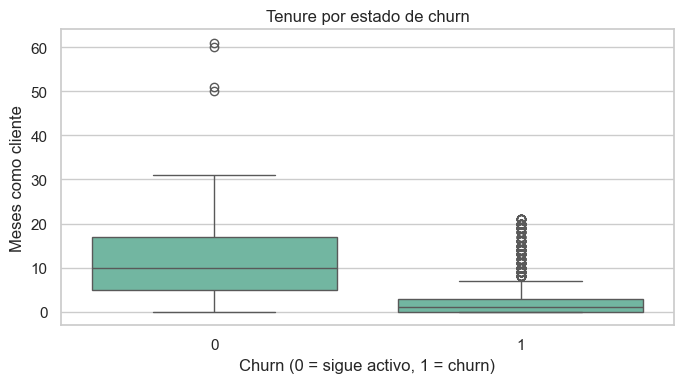

{'feature': 'Tenure',
 'test': 'Mann-Whitney U',
 'n_used': 5366,
 'statistic': np.float64(714994.0),
 'p_value': np.float64(5.680524347167067e-193),
 'effect_size': np.float64(-0.6333959129197748),
 'mean_churn': np.float64(3.3794694348327567),
 'mean_no_churn': np.float64(11.502333851967103),
 'median_churn': np.float64(1.0),
 'median_no_churn': np.float64(10.0)}

In [6]:
h1_result = mann_whitney_test(df, "Tenure")
plot_numeric_by_churn(
    df,
    "Tenure",
    "Tenure por estado de churn",
    "Meses como cliente",
    "h1_tenure_by_churn.png",
)
h1_result

## H2 - Complain

**Hipotesis:** Los clientes con reclamos tienden a churnear mas.

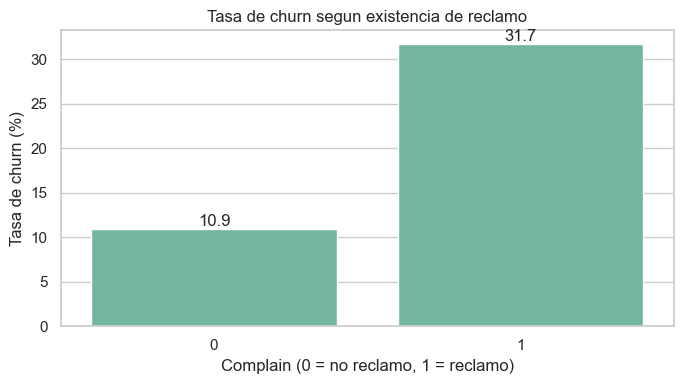

,Complain,clientes,churn_rate_pct
0,0,4026,10.93
1,1,1604,31.67


{'feature': 'Complain',
 'test': 'Chi-square',
 'n_used': 5630,
 'statistic': np.float64(350.92545525927073),
 'p_value': np.float64(2.6644609654641377e-78),
 'effect_size': np.float64(0.24966245605686588),
 'dof': 1}

In [7]:
h2_result = chi_square_test(df, "Complain")
h2_rates = plot_rate_by_category(
    df,
    "Complain",
    "Tasa de churn segun existencia de reclamo",
    "Complain (0 = no reclamo, 1 = reclamo)",
    "h2_complain_churn_rate.png",
)
display(h2_rates)
h2_result

## H3 - SatisfactionScore

**Hipotesis:** Los clientes con menor `SatisfactionScore` tienden a churnear mas.

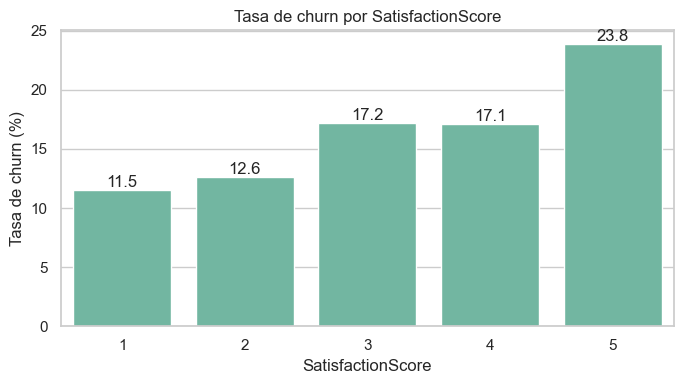

,SatisfactionScore,clientes,churn_rate_pct
0,1,1164,11.51
1,2,586,12.63
2,3,1698,17.20
3,4,1074,17.13
4,5,1108,23.83


{'feature': 'SatisfactionScore',
 'test': 'Chi-square',
 'n_used': 5630,
 'statistic': np.float64(69.8653884066938),
 'p_value': np.float64(2.4233349782737515e-14),
 'effect_size': np.float64(0.11139785834165415),
 'dof': 4}

In [8]:
h3_result = chi_square_test(df, "SatisfactionScore")
h3_rates = plot_rate_by_category(
    df,
    "SatisfactionScore",
    "Tasa de churn por SatisfactionScore",
    "SatisfactionScore",
    "h3_satisfaction_churn_rate.png",
)
display(h3_rates)
h3_result

## H4 - OrderCount

**Hipotesis:** Los clientes con menor `OrderCount` tienden a churnear mas.

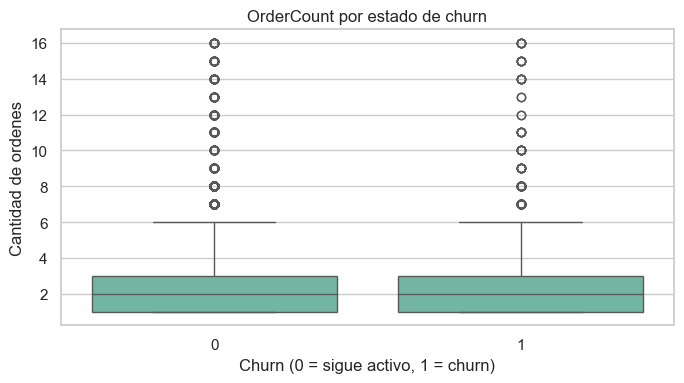

{'feature': 'OrderCount',
 'test': 'Mann-Whitney U',
 'n_used': 5372,
 'statistic': np.float64(1979607.0),
 'p_value': np.float64(0.03636439320979886),
 'effect_size': np.float64(-0.0415985243496827),
 'mean_churn': np.float64(2.8236559139784947),
 'mean_no_churn': np.float64(3.0466006303466906),
 'median_churn': np.float64(2.0),
 'median_no_churn': np.float64(2.0)}

In [9]:
h4_result = mann_whitney_test(df, "OrderCount")
plot_numeric_by_churn(
    df,
    "OrderCount",
    "OrderCount por estado de churn",
    "Cantidad de ordenes",
    "h4_order_count_by_churn.png",
)
h4_result

## H5 - CashbackAmount

**Hipotesis:** Los clientes con menor `CashbackAmount` tienden a churnear mas.

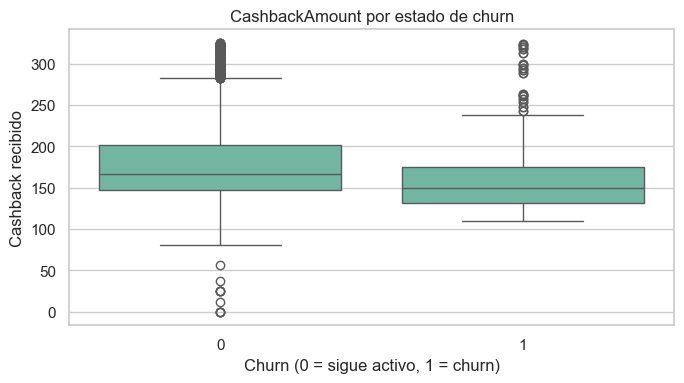

{'feature': 'CashbackAmount',
 'test': 'Mann-Whitney U',
 'n_used': 5630,
 'statistic': np.float64(1628104.0),
 'p_value': np.float64(2.223210470400629e-38),
 'effect_size': np.float64(-0.26637792281058437),
 'mean_churn': np.float64(160.36919831223628),
 'mean_no_churn': np.float64(180.63370354549338),
 'median_churn': np.float64(150.0),
 'median_no_churn': np.float64(166.0)}

In [10]:
h5_result = mann_whitney_test(df, "CashbackAmount")
plot_numeric_by_churn(
    df,
    "CashbackAmount",
    "CashbackAmount por estado de churn",
    "Cashback recibido",
    "h5_cashback_by_churn.png",
)
h5_result

## H6 - DaySinceLastOrder

**Hipotesis:** Los clientes con mas dias desde su ultima orden tienden a churnear mas.

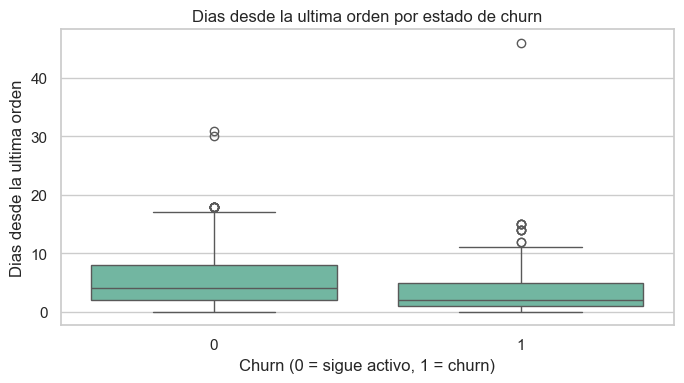

{'feature': 'DaySinceLastOrder',
 'test': 'Mann-Whitney U',
 'n_used': 5323,
 'statistic': np.float64(1412515.0),
 'p_value': np.float64(2.954663955827149e-42),
 'effect_size': np.float64(-0.2865231848458628),
 'mean_churn': np.float64(3.2360178970917226),
 'mean_no_churn': np.float64(4.807405734928878),
 'median_churn': np.float64(2.0),
 'median_no_churn': np.float64(4.0)}

In [11]:
h6_result = mann_whitney_test(df, "DaySinceLastOrder")
plot_numeric_by_churn(
    df,
    "DaySinceLastOrder",
    "Dias desde la ultima orden por estado de churn",
    "Dias desde la ultima orden",
    "h6_days_since_last_order_by_churn.png",
)
h6_result

## Resumen de validacion de hipotesis

Esta tabla resume los tests. La interpretacion final no debe basarse solo en p-valor: tambien hay que mirar direccion del efecto, tama?o de efecto y sentido de negocio.

In [12]:
hypothesis_results = pd.DataFrame([
    {"hypothesis": "H1", "expected_direction": "Churn=1 con menor Tenure", **h1_result},
    {"hypothesis": "H2", "expected_direction": "Complain=1 con mayor churn rate", **h2_result},
    {"hypothesis": "H3", "expected_direction": "Scores bajos con mayor churn rate", **h3_result},
    {"hypothesis": "H4", "expected_direction": "Churn=1 con menor OrderCount", **h4_result},
    {"hypothesis": "H5", "expected_direction": "Churn=1 con menor CashbackAmount", **h5_result},
    {"hypothesis": "H6", "expected_direction": "Churn=1 con mayor DaySinceLastOrder", **h6_result},
])

summary_cols = ["hypothesis", "feature", "test", "n_used", "p_value", "effect_size", "expected_direction"]
hypothesis_results[summary_cols].assign(p_value=lambda x: x["p_value"].map(format_pvalue))

,hypothesis,feature,test,n_used,p_value,effect_size,expected_direction
0,H1,Tenure,Mann-Whitney U,5366,< 0.001,-0.633396,Churn=1 con menor Tenure
1,H2,Complain,Chi-square,5630,< 0.001,0.249662,Complain=1 con mayor churn rate
2,H3,SatisfactionScore,Chi-square,5630,< 0.001,0.111398,Scores bajos con mayor churn rate
3,H4,OrderCount,Mann-Whitney U,5372,0.0364,-0.041599,Churn=1 con menor OrderCount
4,H5,CashbackAmount,Mann-Whitney U,5630,< 0.001,-0.266378,Churn=1 con menor CashbackAmount
5,H6,DaySinceLastOrder,Mann-Whitney U,5323,< 0.001,-0.286523,Churn=1 con mayor DaySinceLastOrder


## Exploracion complementaria para revision manual

Este bloque no crea hipotesis nuevas. Solo ordena variables por asociacion inicial con churn para que el equipo revise si aparece algun patron que valga la pena investigar manualmente.

In [13]:
numeric_features = [
    col for col in df.select_dtypes(include=["number"]).columns
    if col not in ["CustomerID", TARGET]
]

numeric_screening = pd.DataFrame([mann_whitney_test(df, col) for col in numeric_features])
numeric_screening = numeric_screening.sort_values("p_value")
numeric_screening[[
    "feature", "p_value", "effect_size", "median_churn", "median_no_churn", "n_used"
]].assign(p_value=lambda x: x["p_value"].map(format_pvalue)).head(12)

,feature,p_value,effect_size,median_churn,median_no_churn,n_used
0,Tenure,< 0.001,-0.633396,1.0,10.0,5366
7,Complain,< 0.001,0.301777,1.0,0.0,5630
11,DaySinceLastOrder,< 0.001,-0.286523,2.0,4.0,5323
12,CashbackAmount,< 0.001,-0.266378,150.0,166.0,5630
5,SatisfactionScore,< 0.001,0.157438,3.0,3.0,5630
4,NumberOfDeviceRegistered,< 0.001,0.147630,4.0,4.0,5630
1,CityTier,< 0.001,0.109633,1.0,1.0,5630
2,WarehouseToHome,< 0.001,0.127370,15.0,13.0,5379
6,NumberOfAddress,0.0305,0.043838,3.0,3.0,5630
10,OrderCount,0.0364,-0.041599,2.0,2.0,5372


In [14]:
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
categorical_screening = pd.DataFrame([chi_square_test(df, col) for col in categorical_features])
categorical_screening = categorical_screening.sort_values("p_value")
categorical_screening[["feature", "p_value", "effect_size", "dof", "n_used"]].assign(
    p_value=lambda x: x["p_value"].map(format_pvalue)
)

,feature,p_value,effect_size,dof,n_used
3,PreferedOrderCat,< 0.001,0.226425,5,5630
4,MaritalStatus,< 0.001,0.183062,2,5630
0,PreferredLoginDevice,< 0.001,0.114287,2,5630
1,PreferredPaymentMode,< 0.001,0.117627,6,5630
2,Gender,0.0308,0.028779,1,5630


## Cierre para revision manual

Preguntas para revisar antes de escribir conclusiones:

1. Que hipotesis se sostienen en direccion esperada y con tama?o de efecto relevante?
2. Que hipotesis son estadisticamente significativas pero tienen una historia de negocio debil?
3. Hay alguna hipotesis cuyo resultado salga en direccion contraria a lo esperado?
4. Que variables de la exploracion complementaria merecen una revision manual adicional?
